# Grid Adventure V1 Tutorial

This notebook introduces the **Grid Adventure V1** game. It consists of:

1. Understanding **GridState** and how to navigate and build the grid representation
2. **Tutorial levels** to learn interactions between entities in the game.

The goal is to help you understand how the environment works before writing your own agent.

Before we begin, we first import the necessary modules from Grid Adventure V1.

In [1]:
# GridState is the main representation of the game state
from grid_adventure.grid import GridState
from grid_adventure.grid import to_state
from grid_adventure.grid import step
from grid_adventure.actions import Action
# Movements and Objectives are gridstate parameters. For Grid Adventure V1, we will be using the default ones.
from grid_adventure.movements import MOVEMENTS
from grid_adventure.objectives import OBJECTIVES

#Next, we import the methods to create the various entities in the game.
from grid_adventure.entities import (
    AgentEntity,
    FloorEntity,
    WallEntity,
    ExitEntity,
    CoinEntity,
    GemEntity,
    KeyEntity,
    LockedDoorEntity,
    LavaEntity,
    BoxEntity,
    SpeedPowerUpEntity,
    ShieldPowerUpEntity,
    PhasingPowerUpEntity,
)

# Rendering and display
from grid_adventure.rendering import ImageRenderer
from IPython.display import display

# Asset root for rendering. You can specify your own asset folder path if you want to use custom game assets.
from grid_adventure.rendering import DEFAULT_ASSET_ROOT

# Default renderer used throughout the notebook unless overridden in a cell
renderer = ImageRenderer(resolution=240, asset_root=DEFAULT_ASSET_ROOT)

## GridState Representation

The game world is represented as a **2D grid**. Each grid cell can contain **multiple entities**.

### GridState Attributes

A `GridState` object contains three groups of attributes:

**Configuration**
- `width`: The number of columns in the grid
- `height`: The number of rows in the grid
- `movement`: Movement of the agent. For Grid Adventure V1, we use the default cardinal movement.
- `objective`: Objective function for the game. For Grid Adventure V1, we use default objective function (Collect any gems if present then move to exit tile)
- `seed`: Seed for the GridState, for reproducibility

**Grid Structure**
- `grid`: a 2D list where each cell contains a list of entities

**Global Attributes**
- `turn`
- `score`
- `win`, `lose`
- `message`
- `turn_limit`

### Navigating GridState

To create a grid, you must specify:
- `width` and `height`, both integers
- A movement function (cardinal movement)
- An objective function (collect all gems and exit)
- A seed

To add objects to the grid, `add(pos, obj)` or `add_many(items)` can be used.
`remove(pos, obj)` can be used to remove any objects on the grid as well.

Each cell in the grid can contain **multiple entities**, and they are stored as a list in GridState.

- Positions are always expressed as `(x, y)`
- You can inspect a cell using `objects_at((x, y))`, which returns a list of entities
- Global attributes such as `height`, `width`, `turn` and `score` can be accessed directly from `GridState`

---

#### Rendering the GridState

The `ImageRenderer` can be used to visually render the grid. Rendering the image can help in visualising game actions or debugging.
To render a GridState, it must be first converted to an immutable type using `to_state` function.

---

The full documentation and all available methods and attributes can be found in [Agent Documentation](https://grid-universe.github.io/grid-adventure-v1/agent-doc/introduction/).

An example is given below to understand the GridState representation.

Grid size: 5 x 4
Turn: 0
Score: 0
Entities at (3, 2): ['floor', 'wall']


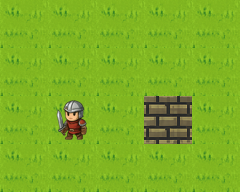

In [2]:
# Creating a 5x4 grid
gridstate_1_1 = GridState(
    width=5,
    height=4,
    movement=MOVEMENTS["cardinal"],
    objective=OBJECTIVES["collect_gems_and_exit"],
    seed=0,
)

# Populate every cell with floor
for x in range(gridstate_1_1.width):
    for y in range(gridstate_1_1.height):
        gridstate_1_1.add((x, y), FloorEntity())

# Add an agent and a wall
gridstate_1_1.add((1, 2), AgentEntity())
gridstate_1_1.add((3, 2), WallEntity())

# Inspect grid details
print("Grid size:", gridstate_1_1.width, "x", gridstate_1_1.height)
print("Turn:", gridstate_1_1.turn)
print("Score:", gridstate_1_1.score)

# Inspect a specific cell
entities_at_3_2 = gridstate_1_1.objects_at((3, 2))
print("Entities at (3, 2):", [e.appearance.name for e in entities_at_3_2])

# Render and display the grid
display(renderer.render(to_state(gridstate_1_1)))

### Actions

Agents have 7 possible moves to make at any point in the game:

| Action | Meaning |
|------|--------|
| UP / DOWN / LEFT / RIGHT | Move |
| PICK_UP | Collect items |
| USE_KEY | Unlock door |
| WAIT | Do nothing |

Each action made uses 1 turn, even if the action is wasted.

To make an action in GridState, the `step(GridState, Action)` function can be used. It returns a new GridState after the action is performed. 

Start:
 win: False


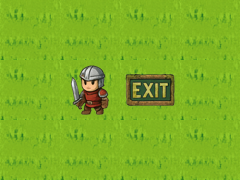

After 1 move to the right:
 win: True


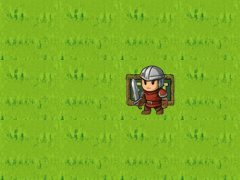

In [3]:
gridstate_1_2 = GridState(width=4, height=3, movement=MOVEMENTS["cardinal"], objective=OBJECTIVES["collect_gems_and_exit"], seed=0)
for x in range(gridstate_1_2.width):
    for y in range(gridstate_1_2.height):
        gridstate_1_2.add((x, y), FloorEntity())

gridstate_1_2.add((1, 1), AgentEntity())
gridstate_1_2.add((2, 1), ExitEntity())

print("Start:\n", "win:", gridstate_1_2.win)
display(renderer.render(to_state(gridstate_1_2)))

# Move 1 step to the RIGHT to reach the exit
gridstate_1_2 = step(gridstate_1_2,Action.RIGHT)
print("After 1 move to the right:\n", "win:", gridstate_1_2.win)
display(renderer.render(to_state(gridstate_1_2)))


### **Scoring and objective**

Agent wins when it collects all gems on the grid and steps on the exit. Your goal is to help it not just win, but win with as high a score as possible.

<details>
<summary>Score calculation</summary>
Each turn taken by the agent has a reward of -3, so the agent should aim to complete the objective with lowest turns possible.

Total score = (-3)* turns + (5)* (coins collected)
</details>


`score` is an attribute of GridState and can be accessed anytime.

The attribute `win` can be used to check if the objective has been met.

## Entities

This section describe entities you will encounter and how the agent interacts with them.

All entities have `appearance.name` attribute, which is a string describing the entity. It can be used to determine the entities present in each cell of the grid. Each entity below is given with its entity class name as well as appearance name in brackets.

When rendering the grid, each entity’s **appearance name** is used to determine which image to display. By default, images are loaded from the `DEFAULT_ASSET_ROOT` defined in `grid_adventure.rendering`, which provides public assets from Grid Adventure V1. A mapping from appearance name is also defined as `IMAGE_MAP` in the same package.


**AgentEntity** (`"human"`)

- Controlled by the player
- Additional attributes
    - **health**: Current HP of the agent
    - **inventory_list**: List of entities that the agent has picked up
    - **status_list**: List of power-up entities that are active

**WallEntity** (`"wall"`)
- Restricts movement, the agent is not able to move into walls

**BoxEntity** (`"box"`)
- The agent cannot move into boxes, but can push them if the space behind them is empty.

**LockedDoorEntity** (`"door"`)
- The agent cannot move through doors when they are locked.
- Requires a key to unlock. Any key can be used to unlock a door, but each key can only be used once. Once unlocked, it becomes a **UnlockedDoorEntity**.
- A door may not be guarding the optimal route.


**LavaEntity** (`"lava"`)

- The agent can walk through Lava, but it takes 2 damage when it does.
- The game is resulted in a loss if agent HP reaches 0.

**CoinEntity** (`"coin"`)
- Coins are optional and can be picked up by the agent. Collecting coins provides a Reward of 5

**GemEntity** (`"gem"`)
- Gems need to be picked up to complete the objective.

**KeyEntity** (`"key"`)
- Keys can be picked up to unlock doors.

**SpeedPowerUpEntity** (`"boots"`)
- Speed allows the agent to move 2 tiles in 1 turn. The agent can still be blocked and still take damage when moving through lava.
- The speed power-up lasts for 5 turns.

**ShieldPowerUpEntity** (`"shield"`)
- Shield provides immunity to damage. When moving through lava, the agent does not take damage but the shield loses 1 durability.
- The shield power-up has 5 usages.

**PhasingPowerUpEntity** (`"ghost"`)
- Phasing allows the agent to pass through entities that restrict movement such as walls, doors.
- Phasing also allows the agent to pass through boxes without pushing them, and pass through lava without taking damage.
- The phasing power-up lasts for 5 turns. 

**ExitEntity** (`"exit"`)
- After collecting all the gems (if any) in the level, reach the Exit tile to complete the objective and win the game.
---

**Tutorial 1**: Finding entities in GridState

In the following code block, gridstate_1_3 is built. An example code is given to locate the Agent entity.

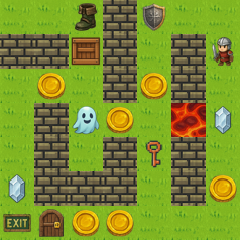

Agent is at position: (6, 1) with health: 5


In [4]:
# Building the grid
gridstate_2_1 = GridState(width=7, height=7, movement=MOVEMENTS["cardinal"], objective=OBJECTIVES["collect_gems_and_exit"], seed=0)
for x in range(gridstate_2_1.width):
    for y in range(gridstate_2_1.height):
        gridstate_2_1.add((x, y), FloorEntity())
gridstate_2_1.add((6, 1), AgentEntity())
gridstate_2_1.add((0, 6), ExitEntity())
wall_pos = [(3, 0),(0, 1),(1, 1),(3, 1),(5, 1),(3, 2),(5, 2),(1, 3),(1, 4),(3, 4),(5, 4),(1, 5),(2, 5),(3, 5),(5, 5)]
for p in wall_pos:
    gridstate_2_1.add(p, WallEntity())
gridstate_2_1.add((2, 1), BoxEntity())
gridstate_2_1.add((0, 5), GemEntity())
gridstate_2_1.add((6, 3), GemEntity())
coin_pos = [(1, 2), (4, 2), (3, 3), (6, 5), (2, 6), (3, 6)]
for p in coin_pos:
    gridstate_2_1.add(p, CoinEntity())
gridstate_2_1.add((2, 0), SpeedPowerUpEntity())
gridstate_2_1.add((2, 3), PhasingPowerUpEntity())
gridstate_2_1.add((4, 0), ShieldPowerUpEntity())
gridstate_2_1.add((4, 4), KeyEntity())
gridstate_2_1.add((1, 6), LockedDoorEntity())
gridstate_2_1.add((5, 3), LavaEntity())
display(renderer.render(to_state(gridstate_2_1)))

# Determine location of Agent
for x in range(gridstate_2_1.width):
    for y in range(gridstate_2_1.height):
        entities = gridstate_2_1.objects_at((x,y))
        for e in entities:
            if isinstance(e, AgentEntity):
                print("Agent is at position:", (x,y), "with health:", e.health.current_health)

Now, try to identify the locations of all coins in the grid.

In [7]:
# TODO: print the positions of all Coins in the grid
coin_positions = []

# Add your code to populate the coin list here
for x in range(gridstate_2_1.width):
    for y in range(gridstate_2_1.height):
        entities = gridstate_2_1.objects_at((x,y))
        for e in entities:
            if isinstance(e, CoinEntity):
                coin_positions.append((x, y))

if set(coin_positions) == set(coin_pos):
    print("Coin positions correctly identified:", coin_positions)

Coin positions correctly identified: [(1, 2), (2, 6), (3, 3), (3, 6), (4, 2), (6, 5)]


**Tutorial 2**: Boxes, Coins, Lava

Try navigating the following grid to reach the objective with highest reward possible.

Note: Boxes can be pushed into Coins but not Lava.

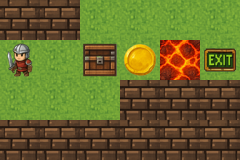

In [16]:
gridstate_2_2 = GridState(width=6, height=4, movement=MOVEMENTS["cardinal"], objective=OBJECTIVES["collect_gems_and_exit"], seed=1)
for x in range(gridstate_2_2.width):
    for y in range(gridstate_2_2.height):
        gridstate_2_2.add((x, y), FloorEntity())
wall_pos = [(0,0),(0,3),(1,0),(1,3),(2,3),(3,2),(3,3),(4,2),(4,3),(5,2),(5,3),]
for p in wall_pos:
    gridstate_2_2.add(p, WallEntity())
gridstate_2_2.add((0, 1), AgentEntity())
gridstate_2_2.add((2, 1), BoxEntity())
gridstate_2_2.add((3, 1), CoinEntity())
gridstate_2_2.add((4, 1), LavaEntity())
gridstate_2_2.add((5, 1), ExitEntity())

display(renderer.render(to_state(gridstate_2_2)))

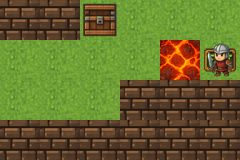

Congratulations! You have solved the grid. Total Score: -16
You have solved the grid in the optimal number of steps!


In [17]:
# TODO: Fill up the list of actions to solve the grid, Use Action.UP, Action.DOWN, Action.LEFT, Action.RIGHT, Action.PICK_UP
actions = [Action.RIGHT, Action.DOWN, Action.RIGHT, Action.UP, Action.RIGHT, Action.PICK_UP, Action.RIGHT, Action.RIGHT]
for a in actions:
    gridstate_2_2 = step(gridstate_2_2, a)
display(renderer.render(to_state(gridstate_2_2)))

if gridstate_2_2.win:
    print("Congratulations! You have solved the grid. Total Score:", gridstate_2_2.score)
    if gridstate_2_2.score == -16:
        print("You have solved the grid in the optimal number of steps!")
    else:
        print("Try to solve the grid in fewer steps to achieve the optimal score.")
else:
    print("The grid is not yet solved. Keep trying!")

**Tutorial 3**: Gems, Keys, Doors, Shield

Try navigating the following grid to complete all objectives. The score does not matter. Note that agent health is set to 1, so landing on Lava without the shield will result in a loss.

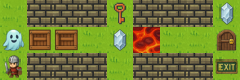

In [184]:
gridstate_2_3 = GridState(width=9, height=3, movement=MOVEMENTS["cardinal"], objective=OBJECTIVES["collect_gems_and_exit"], seed=0)
for x in range(gridstate_2_3.width):
    for y in range(gridstate_2_3.height):
        gridstate_2_3.add((x, y), FloorEntity())
agent = AgentEntity()
agent.set_health(1)
gridstate_2_3.add((0, 2), agent)
wall_positions = [
    (1, 0), (1, 2),
    (2, 0), (2, 2),
    (3, 0), (3, 2),
    (5, 0), (5, 2),
    (6, 0), (6, 2),
    (7, 0), (7, 2),
]
for p in wall_positions:
    gridstate_2_3.add(p, WallEntity())
gridstate_2_3.add((0,1), PhasingPowerUpEntity())
gridstate_2_3.add((1,1), BoxEntity())
gridstate_2_3.add((2,1), BoxEntity())
gridstate_2_3.add((5,1), LavaEntity())

gem_positions = [(4, 1), (8, 0)]
for p in gem_positions:
    gridstate_2_3.add(p, GemEntity())
gridstate_2_3.add((4, 0), KeyEntity())
gridstate_2_3.add((8, 1), LockedDoorEntity())
gridstate_2_3.add((8, 2), ExitEntity())
display(renderer.render(to_state(gridstate_2_3)))

Agent is at position: (0, 1) with health: 1


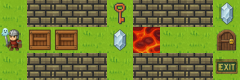

The grid is not yet solved. Keep trying!


In [187]:
# TODO: Fill up the list of actions to solve the grid, Use Action.UP, Action.DOWN, Action.LEFT, Action.RIGHT, Action.PICK_UP, Action.USE_KEY
actions = [Action.RIGHT]
for a in actions:
    gridstate_2_3 = step(gridstate_2_3, a)
    for x in range(gridstate_2_3.width):
        for y in range(gridstate_2_3.height):
            entities = gridstate_2_3.objects_at((x,y))
            for e in entities:
                if isinstance(e, AgentEntity):
                    print("Agent is at position:", (x,y), "with health:", e.health.current_health)

display(renderer.render(to_state(gridstate_2_3)))

if gridstate_2_3.win:
    print("Congratulations! You have solved the grid. Total Score:", gridstate_2_3.score)
else:
    print("The grid is not yet solved. Keep trying!")

**Tutorial 4**: Speed, Phasing

Try navigating the following grid. Use the speed powerup to complete the level with highest reward possible.

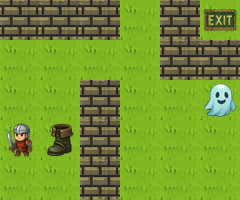

In [22]:
gridstate_2_4 = GridState(width=6, height=5, movement=MOVEMENTS["cardinal"], objective=OBJECTIVES["collect_gems_and_exit"], seed=0)
for x in range(gridstate_2_4.width):
    for y in range(gridstate_2_4.height):
        gridstate_2_4.add((x, y), FloorEntity())

gridstate_2_4.add((0, 3), AgentEntity())
gridstate_2_4.add((1, 3), SpeedPowerUpEntity())
gridstate_2_4.add((5, 0), ExitEntity())
gridstate_2_4.add((5, 2), PhasingPowerUpEntity())
wall_pos = [(0,0),(1,0),(2,0),(2,2),(2,3),(2,4),(4,0),(4,1),(5,1)]
for p in wall_pos:
    gridstate_2_4.add(p, WallEntity())
display(renderer.render(to_state(gridstate_2_4)))

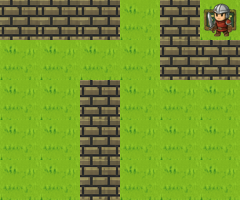

Congratulations! You have solved the grid with highest score. Total Score: -27


In [23]:
actions = [Action.RIGHT, Action.PICK_UP, Action.UP, Action.RIGHT, Action.DOWN, Action.RIGHT, Action.UP, Action.PICK_UP, Action.UP, Action.UP]
for a in actions:
    gridstate_2_4 = step(gridstate_2_4, a)
display(renderer.render(to_state(gridstate_2_4)))
if gridstate_2_4.win:
    if gridstate_2_4.score == -27:
        print("Congratulations! You have solved the grid with highest score. Total Score:", gridstate_2_4.score)
    else:
        print("Try to solve the grid in fewer steps to achieve the optimal score.")
else:
    print("The grid is not yet solved. Keep trying!")

Feel free to add more entities and explore their interactions to fully understand the game. Enjoy gridding!